# REFINE pipeline timing

`run_task_pipeline.sh` prints an `[HH:MM:SS] [task] === Step N: ... ===` marker at the **start** of each of its 10 steps (and a final `=== DONE ===`). The script never records durations directly, so this notebook **recovers per-step time by subtracting consecutive timestamps** in each `data/logs/<task>.log`:

$$\text{duration}(\text{step}_i) = t(\text{step}_{i+1}) - t(\text{step}_i)$$

with step 10's duration measured to the `DONE` marker. Timestamps are 1-second granularity and carry no date, so we add 24h whenever the clock wraps past midnight.

Each log holds one run, so the distribution at each step is **across tasks** (one point per task). The violin shows that spread; the table gives the summary statistics.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo-root data/logs whether the notebook is run from notebooks/ or repo root.
_here = os.getcwd()
LOG_DIR = next(
    p for p in (os.path.join(_here, 'data/logs'), os.path.join(_here, '../data/logs'))
    if os.path.isdir(p)
)
sns.set_theme(style='whitegrid')
print('Reading logs from:', os.path.abspath(LOG_DIR))
print('Found:', sorted(os.path.basename(p) for p in glob.glob(os.path.join(LOG_DIR, '*.log'))))

Reading logs from: /Users/ryannayebi/Downloads/STANFORD/research/fries/refine/data/logs
Found: ['guo_los.log', 'guo_readmission.log', 'lab_hyperkalemia.log', 'new_lupus.log']


In [2]:
# Matches the log() markers emitted by run_task_pipeline.sh:
#   [HH:MM:SS] [task] === Step N: Title ===   and   [HH:MM:SS] [task] === DONE ===
MARKER = re.compile(
    r'^\[(\d{2}):(\d{2}):(\d{2})\]\s+\[[^\]]+\]\s+===\s+(?:Step\s+(\d+):\s+(.*?)|(DONE))\s+==='
)
# Sub-markers inside the two GPU steps (4 and 9) — let us split lock-wait from compute.
LOCK = re.compile(r'^\[(\d{2}):(\d{2}):(\d{2})\]\s+\[[^\]]+\]\s+\[GPU lock (acquired|released)\]')


def _cumulative(times):
    """Seconds-of-day list -> monotonic seconds, adding 24h on each midnight wrap."""
    out, day, prev = [], 0, None
    for sod in times:
        if prev is not None and sod < prev:
            day += 1
        prev = sod
        out.append(day * 86400 + sod)
    return out


def parse_log(path):
    task = os.path.basename(path).replace('.log', '')
    raw = []        # (sod, step_or_None, title)  -- step markers + DONE, in file order
    locks = []      # (sod, kind)                 -- GPU lock acquired/released
    with open(path) as f:
        for line in f:
            m = MARKER.match(line)
            if m:
                sod = int(m[1]) * 3600 + int(m[2]) * 60 + int(m[3])
                if m[6] == 'DONE':
                    raw.append((sod, None, 'DONE'))
                else:
                    raw.append((sod, int(m[4]), m[5].strip()))
                continue
            lm = LOCK.match(line)
            if lm:
                locks.append((int(lm[1]) * 3600 + int(lm[2]) * 60 + int(lm[3]), lm[4]))

    cum = _cumulative([sod for sod, _, _ in raw])
    rows = []
    for i in range(len(raw) - 1):          # last event is DONE -> nothing after it
        _, step, title = raw[i]
        if step is None:
            continue
        rows.append(dict(task=task, step=step, title=title,
                         duration_s=cum[i + 1] - cum[i]))
    return rows, task, locks


records, lock_records = [], []
for path in sorted(glob.glob(os.path.join(LOG_DIR, '*.log'))):
    rows, task, locks = parse_log(path)
    records += rows
    # Pair acquired/released to get wait (step start -> acquired) and compute (acquired -> released).
    starts = {r['step']: None for r in rows}
    for r in rows:
        starts[r['step']] = r
    for j in range(0, len(locks) - 1, 2):
        (acq, ka), (rel, kr) = locks[j], locks[j + 1]
        if ka == 'acquired' and kr == 'released':
            lock_records.append(dict(task=task, acquired=acq, released=rel,
                                     compute_s=(rel - acq) % 86400))

df = pd.DataFrame(records)
# Short, stable label per step number (derived from data, not hard-coded).
step_titles = (df.sort_values('task').groupby('step')['title'].first())
df['label'] = df['step'].map(lambda s: f"{s}. {step_titles[s][:24]}")
df.head(12)

,task,step,title,duration_s,label
0,guo_los,1,Select patients,0,1. Select patients
1,guo_los,2,Serialize EHRs,6,2. Serialize EHRs
2,guo_los,3,Create naivetext SFT,0,3. Create naivetext SFT
3,guo_los,4,Generate naivetext embeddings (GPU),626,4. Generate naivetext embed
4,guo_los,5,Build cohort,3,5. Build cohort
5,guo_los,6,Create rubric template,292,6. Create rubric template
6,guo_los,7,Apply rubric (Gemini batch),3493,7. Apply rubric (Gemini bat
7,guo_los,8,Create global-rubric SFT,0,8. Create global-rubric SFT
8,guo_los,9,Generate rubric embeddings (GPU),109,9. Generate rubric embeddin
9,guo_los,10,Evaluate — LogReg AUROC on rubric embeddings,9,10. Evaluate — LogReg AUROC


In [3]:
# Wide view: rows = step, cols = task, values = seconds.
pivot = df.pivot(index='label', columns='task', values='duration_s').sort_index(
    key=lambda idx: [int(s.split('.')[0]) for s in idx]
)
pivot.assign(total=pivot.sum(axis=1)).style.format('{:.0f}s').background_gradient(cmap='Reds', axis=None)

task,guo_los,guo_readmission,lab_hyperkalemia,new_lupus,total
label,,,,,
1. Select patients,0s,0s,1s,0s,1s
2. Serialize EHRs,6s,6s,39s,105s,156s
3. Create naivetext SFT,0s,1s,0s,0s,1s
4. Generate naivetext embed,626s,1581s,337s,491s,3035s
5. Build cohort,3s,4s,2s,3s,12s
6. Create rubric template,292s,128s,131s,145s,696s
7. Apply rubric (Gemini bat,3493s,2711s,2710s,1267s,10181s
8. Create global-rubric SFT,0s,1s,0s,0s,1s
9. Generate rubric embeddin,109s,276s,118s,49s,552s


In [4]:
# Per-step summary statistics (across tasks), seconds.
summary = (df.groupby(['step', 'label'])['duration_s']
             .agg(n='count', mean='mean', median='median', std='std',
                  min='min', max='max')
             .reset_index().sort_values('step'))
summary['share_%'] = 100 * summary['mean'] / summary['mean'].sum()
summary.style.format({'mean': '{:.1f}', 'median': '{:.1f}', 'std': '{:.1f}',
                      'min': '{:.0f}', 'max': '{:.0f}', 'share_%': '{:.1f}%'}).hide(axis='index')

step,label,n,mean,median,std,min,max,share_%
1,1. Select patients,4,0.2,0.0,0.5,0,1,0.0%
2,2. Serialize EHRs,4,39.0,22.5,46.7,6,105,1.1%
3,3. Create naivetext SFT,4,0.2,0.0,0.5,0,1,0.0%
4,4. Generate naivetext embed,4,758.8,558.5,560.7,337,1581,20.7%
5,5. Build cohort,4,3.0,3.0,0.8,2,4,0.1%
6,6. Create rubric template,4,174.0,138.0,79.0,128,292,4.7%
7,7. Apply rubric (Gemini bat,4,2545.2,2710.5,928.6,1267,3493,69.4%
8,8. Create global-rubric SFT,4,0.2,0.0,0.5,0,1,0.0%
9,9. Generate rubric embeddin,4,138.0,113.5,97.0,49,276,3.8%
10,10. Evaluate — LogReg AUROC,4,10.5,9.0,3.7,8,16,0.3%


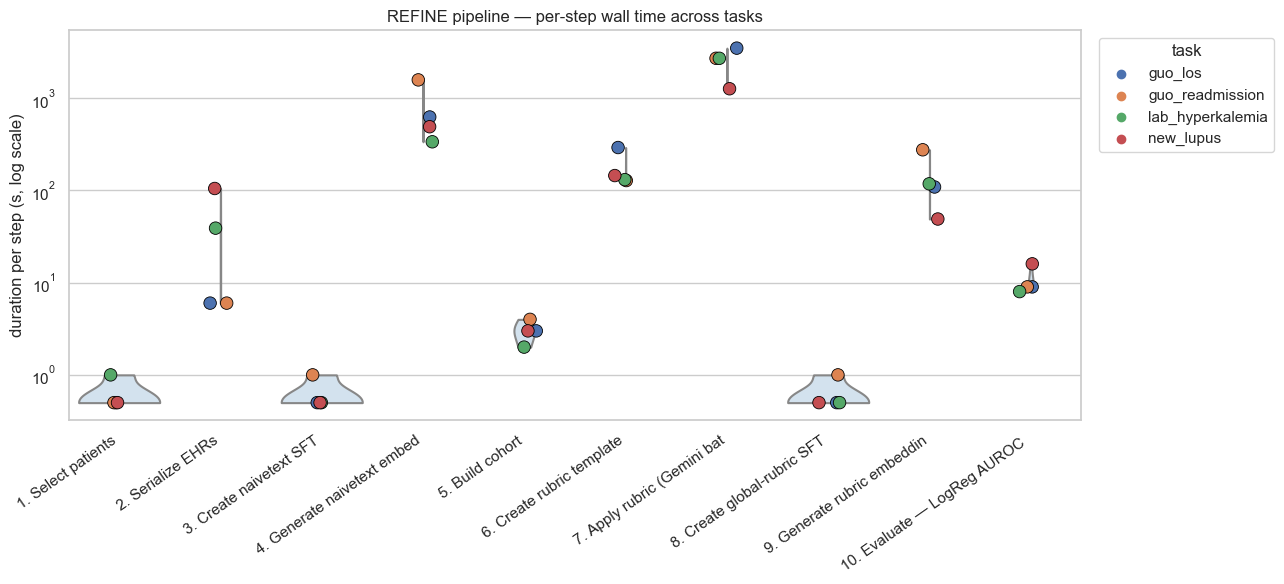

In [5]:
# Violin of per-step duration across tasks. Durations span ~0s to ~1h, so use a log
# y-axis (sub-second steps floored to 0.5s) to keep every step's spread visible.
plot_df = df.copy()
plot_df['dur_clip'] = plot_df['duration_s'].clip(lower=0.5)
order = [step_titles.index.map(lambda s: f"{s}. {step_titles[s][:24]}")[i]
         for i in range(len(step_titles))]

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=plot_df, x='label', y='dur_clip', order=order,
               inner=None, cut=0, density_norm='width', color='#cfe3f2', ax=ax)
sns.stripplot(data=plot_df, x='label', y='dur_clip', order=order,
              hue='task', size=9, jitter=0.12, edgecolor='black',
              linewidth=0.6, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('duration per step (s, log scale)')
ax.set_xlabel('')
ax.set_title('REFINE pipeline — per-step wall time across tasks')
ax.tick_params(axis='x', rotation=35)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')
ax.legend(title='task', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

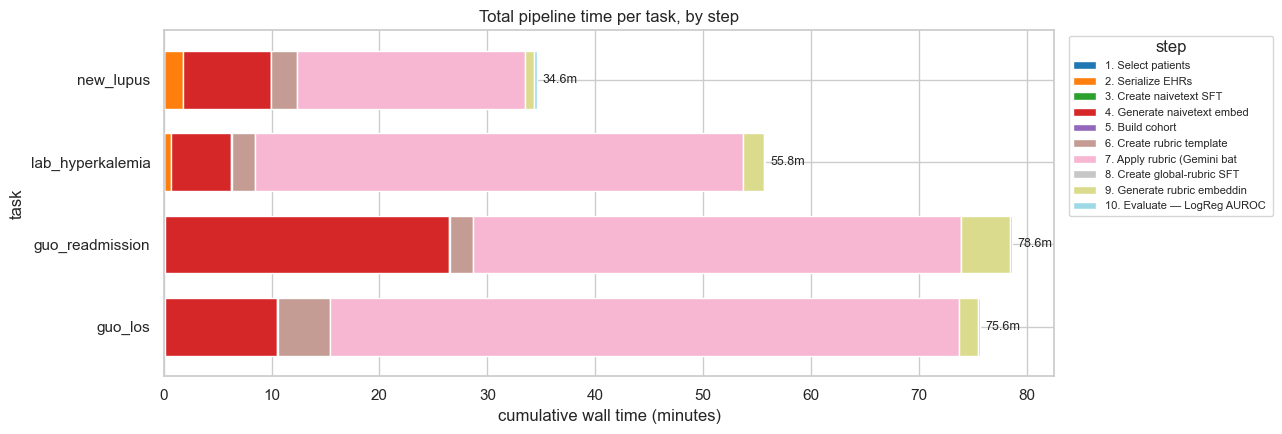

In [6]:
# Where does the wall-clock go? Stacked per-task total, split by step.
stack = df.pivot_table(index='task', columns='label', values='duration_s', aggfunc='sum')
stack = stack[order] / 60.0  # minutes
ax = stack.plot(kind='barh', stacked=True, figsize=(13, 4.5), colormap='tab20', width=0.7)
ax.set_xlabel('cumulative wall time (minutes)')
ax.set_title('Total pipeline time per task, by step')
ax.legend(title='step', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, fontsize=8)
for task, total in stack.sum(axis=1).items():
    ax.text(total + 0.5, list(stack.index).index(task), f'{total:.1f}m', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# GPU steps (4 & 9) carry [GPU lock acquired]/[released] sub-markers, so we can split
# lock-wait (queuing behind another tmux session) from actual embedding compute.
lk = pd.DataFrame(lock_records)
if lk.empty:
    print('No GPU lock sub-markers found.')
else:
    lk['gpu_step'] = lk.groupby('task').cumcount().map({0: '4 (naivetext)', 1: '9 (rubric)'})
    display(lk[['task', 'gpu_step', 'compute_s']]
            .pivot(index='task', columns='gpu_step', values='compute_s')
            .style.format('{:.0f}s').set_caption('GPU compute time (acquired -> released), seconds'))

gpu_step,4 (naivetext),9 (rubric)
task,,
guo_los,626s,109s
guo_readmission,956s,179s
lab_hyperkalemia,337s,118s
new_lupus,491s,49s
